# Использование локальной VLLM для задачи OCR

Данная работа выполнена студентов ИАД-4 Коноваловым Матвеем

Модели разрешено брать с https://huggingface.co, при этом для меня задача усложняется тем, что я выполняю работу на mac-е, а большая часть моделей там заточена под CUDA.

Тем не менее, mlx-community предоставляет модели специально под mac.

## Примеры изображений

|                                            |                                              |
|--------------------------------------------|----------------------------------------------|
| ![IMG_2694.jpg](pictures_iad/IMG_2694.jpg) | ![IMG_2695.jpg](pictures_iad/IMG_2695.jpg)   |
| ![IMG_2696.jpg](pictures_iad/IMG_2696.jpg) | ![IMG_99999.jpg](pictures_iad/IMG_99999.jpg)


## Пайплайн решения задачи
Фактически, задачу можно решить двумя способами:
- использовать слабую модель VLM, но помочь ей хорошим preprocessing
- использовать сильную VLM, которая нуждается в минимальном препроцессинге или не нуждается в нем полностью
Просто слабая модель справилась бы с идеальными картинками, а здесь они очень далеко от идеала.

Изначально я выбрал первый подход и пытался с помощью препроцессинга решить следующие проблемы с изображениями:

### Маркер поверх текста
Использовалась разница в насыщенности, цвете, ширине штриха для отделения маркера от текста.

Текст под маркером имел другие threshold-ы для выделения по сравнению с остальным текстом.

### Cлабая контрастность самого текста и малая его площадь по сравнению со всем изображением
Решается выделением области с текстом. Правда сложный фон очень существенно усложняет эту задачу.

### Неудачный поворот изображения
Тут можно попробовать найти углы листа, к примеру опираясь на тот факт, что лист это белый прямоугольник на более темном фоне.

Здесь задачу существенно усложнял блик на фоне, который имеет почти одинаковый с листом цвет, и тень на листе, которая тем более создаёт перепады и не даёт отличить фон от листа.

## Итог подхода с препроцессингом
Идеально бы было построить бинарную маску текста на изображении, или хотя бы подавить часть проблем, вроде маркера.

В итоге ни один из испробованных подходов решения проблем не дал хорошего результата. Вот несколько примеров обработаных изображений:

|     |     |
| --- | --- |
|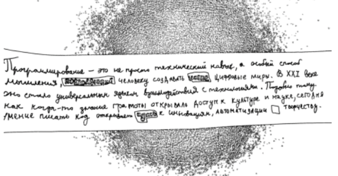|     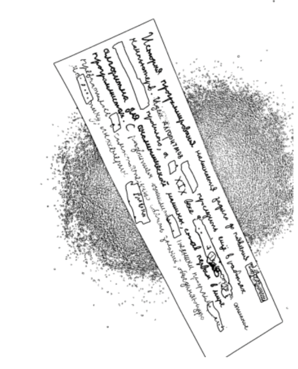|

## Новый подход
В результате было решено сконцентрировать силы на поиске подходящей модели.

В случае, если модель, которая выполняет задачу хорошо на заданных изображениях, найти не удастся, будем использовать частичный препроцессинг. Иначе можно ограничиться одной моделью.

## Загрузка модели

Очень важно сформировать правильные критерии для поиска модели. К примеру, здесь важно:
- Image-Text-to-Text тип модели
- MLX библиотека, т.к. работа выполняется на MacOS
- язык русский; некоторые из выбранных без этого критерия моделей не распознавали текст вовсе или делали это плохо

Итоговый запрос выглядит так: https://huggingface.co/models?pipeline_tag=image-text-to-text&library=mlx&language=ru&sort=trending

Была выбрана одна из топовых в этом списке моделей, https://huggingface.co/TheCluster/Qwen3.5-9B-Uncensored-HauhauCS-Aggressive-MLX-mxfp4.

In [ ]:
!pip install mlx_vlm

In [8]:
!hf auth login


    _|    _|  _|    _|    _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|_|_|_|    _|_|      _|_|_|  _|_|_|_|
    _|    _|  _|    _|  _|        _|          _|    _|_|    _|  _|            _|        _|    _|  _|        _|
    _|_|_|_|  _|    _|  _|  _|_|  _|  _|_|    _|    _|  _|  _|  _|  _|_|      _|_|_|    _|_|_|_|  _|        _|_|_|
    _|    _|  _|    _|  _|    _|  _|    _|    _|    _|    _|_|  _|    _|      _|        _|    _|  _|        _|
    _|    _|    _|_|      _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|        _|    _|    _|_|_|  _|_|_|_|

    To log in, `huggingface_hub` requires a token generated from https://huggingface.co/settings/tokens .
Enter your token (input will not be visible): 

In [2]:
# Использовался пример использования библиотеки из официального репозитория: https://github.com/Blaizzy/mlx-vlm

import mlx.core as mx
from mlx_vlm import load, generate
from mlx_vlm.prompt_utils import apply_chat_template
from mlx_vlm.utils import load_config

image_paths = [
    "pictures_iad/IMG_2694.jpg",
    "pictures_iad/IMG_2695.jpg",
    "pictures_iad/IMG_2696.jpg",
    "pictures_iad/IMG_2697.jpg",
    "pictures_iad/IMG_99998.jpg",
    "pictures_iad/IMG_99999.jpg",
]

# Load the model
model_path = "TheCluster/Qwen3.5-9B-Uncensored-HauhauCS-Aggressive-MLX-mxfp4"
model, processor = load(model_path)
config = load_config(model_path)


# image = [Image.open("...")] can also be used with PIL.Image.Image objects
prompt = "Напиши текст, который ты видишь на изображении. В ответе должен быть только текст на русском языке. Переносы строк надо сохранить."

hyps1 = []
for image_path in image_paths:
    # Prepare input
    image = [image_path]
    # Apply chat template
    formatted_prompt = apply_chat_template(
        processor, config, prompt, num_images=len(image)
    )
    # Generate output
    output = generate(model, processor, formatted_prompt, image, verbose=False).text
    print(output)
    hyps1.append(output)

Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]

Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]


Prefill: 100%|█████████▉| 11890/11891 [02:02<00:00, 97.05tok/s] 


Современные языки программирования, такие как Python, Java и С++, позволяют решать широкий спектр задач - от создания веб-сайтов до разработки сложных систем искусственного интеллекта. Каждый язык обладает своей философией и область применения, но все они основаны на общих принципах: алгоритмах, структурах данных и логике.



Prefill: 100%|█████████▉| 11890/11891 [01:54<00:00, 103.63tok/s]


Программирование — это не просто технический навык, а особый способ мышления, позволяющий человеку создавать новые цифровые миры. В XXI веке оно стало универсальным языком взаимодействия с технологиями. Подобно тому как когда-то знание грамоты открывало доступ к культуре и науке, сегодня умение писать код открывает путь к инновациям, автоматизации и творчеству.



Prefill: 100%|█████████▉| 11890/11891 [01:55<00:00, 103.28tok/s]


Начать программировать можно с алгоритмов.
Алгоритмы в XIX веке
создавали, а потом
вводили в код.
Создавали
алгоритмы, потом
вводили в код.
АНА Лавлейс
создала описание
алгоритмов, потом
вводила в код.
Создавали
алгоритмы, потом
вводили в код.
АНА Лавлейс
создала описание
алгоритмов, потом
вводила в код.
Создавали
алгоритмы, потом
вводили в код.
АНА Лавлейс
создала описание
алгоритмов, потом
вводила в код.
Создавали
алгоритмы, потом
вводили в код.
АНА Лавлейс
создала описание
алгоритмов, потом
вводила в код.
Создавали
алгоритмы, потом
вводили в код.
АНА Лавлейс
создала описание
алгоритмов, потом
вводила в код.
Соз



Prefill: 100%|█████████▉| 11890/11891 [01:52<00:00, 105.25tok/s]


Это первая домашка на ИАДе.
Она, кажется, простая, но пока никто её не решил...
Сотворить совсем не зависит от того,
сколько мы едим, а от того, как мы едим!
Так и счастье, так и счастье, Лёвушка,
оно вовсе не зависит от объёма
внешних благ, которые мы урвали у
жизни. Оно зависит только от нашего
отношение к ним! Об этом сказано ещё в
даосской этике: «Кто умеет
довольствоваться, тот всегда будет
доволен.
При наличии уважительной причины зетлайн ко
8/3 может быть перенесен. Зетлайн ко 8/3 переносится
на кол-во дней, равное продолжительности ув. причины.


In [5]:
hyps1

['Современные языки программирования, такие как Python, Java и С++, позволяют решать широкий спектр задач - от создания веб-сайтов до разработки сложных систем искусственного интеллекта. Каждый язык обладает своей философией и область применения, но все они основаны на общих принципах: алгоритмах, структурах данных и логике.',
 'Программирование — это не просто технический навык, а особый способ мышления, позволяющий человеку создавать новые цифровые миры. В XXI веке оно стало универсальным языком взаимодействия с технологиями. Подобно тому как когда-то знание грамоты открывало доступ к культуре и науке, сегодня умение писать код открывает путь к инновациям, автоматизации и творчеству.',
 'Начать программировать можно с алгоритмов.\nАлгоритмы в XIX веке\nсоздавали, а потом\nвводили в код.\nСоздавали\nалгоритмы, потом\nвводили в код.\nАНА Лавлейс\nсоздала описание\nалгоритмов, потом\nвводила в код.\nСоздавали\nалгоритмы, потом\nвводили в код.\nАНА Лавлейс\nсоздала описание\nалгоритмов, 

## Проверка качества модели

In [ ]:
!pip install cer

In [3]:
# В hyps поместите выводы вашей модели, можете копирнуть руками, можете скриптом пройтись циклом по фото в датасете
# Я не хотел перезаписывать и хотел потом посравнивать, так что записал в hyp1
from cer import calculate_cer_corpus


hyps = ["Современные языки программирования, такие как Python, Java и C++, позволяют решать широкий спектр задач — от создания веб-сайтов до разработки сложных систем искусственного интеллекта. Каждый язык обладает своей философией и областью применения, но все они основываются на общих принципах: алгоритмах, структурах данных и т.д.",
"Программирование — это не просто технический кавер, а особый способ мышления, позволяющий человеку создавать новые цифровые миры. В XXI веке оно стало универсальным языком взаимодействия с технологиями. Подобно тому как когда-то знание грамоты открывало доступ к культуре и науке, сегодня умение писать код открывает путь к инновациям, автоматизации и творчеству.",
"""История готтифицированных монашествующих жирово по гробам, аграрников.
Ханатоньчка, вышито альфонзом в XII веке 900—900г. до сорта, отличие.
Алгарибина докопыриванин визы в тюбик.
Готтификованнота. С разделением ватанскатах, соровы саран, саран.
Аллакофонны и тонь.
Адъноратная академия а пину.

История готтифицированных монашествующих жирово по гробам, аграрников.
Ханатоньчка, вышито альфонзом в XII веке 900—900г. до сорта, отличие.
Алгарибина докопыриванин визы в тюбик.
Готтификованнота. С разделением ватанскатах, соровы саран, саран.
Аллакофонны и тонь.
Адъноратная академия а пину.""",
"""Это первая домашка на ИАДе.
Она, кажется, простая, но пока никто её
не решил...""",
"""Сытость совсем не зависит от того,
сколько мы едим, а от того, как мы едим!
Так и счастье, так и несчастье, Лёвушка,
оно вовсе не зависит от обилия
внешних благ, которые мы урваем у
жизни. Оно зависит только от нашего
отношения к ним! Абсолютно сказано ещё в
давней этике: «Кто умеет
довольствоваться, тот всегда будет
доволен.""",
"""При наличии уважительной причины дедлайн на
8/3 может быть перенесен. Дедлайн на 8/3 переносится
на количество дней, равное продолжительности ув. причины."""]

refs = ["""Современные языки программирования, такие как Python, Java и C++, позволяют решать широкий спектр задач — от создания веб-сайтов до разработки сложных систем искусственного интеллекта. Каждый язык обладает своей философией и областью применения, но все они основаны на общих принципах: алгоритмах, структурах данных и логике.""",
"""Программирование — это не просто технический навык, а особый способ мышления, позволяющий человеку создавать новые цифровые миры. В XXI веке оно стало универсальным языком взаимодействия с технологиями. Подобно тому как когда-то знание грамоты открывало доступ к культуре и науке, сегодня умение писать код открывает путь к инновациям, автоматизации и творчеству.""",
"""История программирования начинается задолго до появления современных компьютеров. Идеи алгоритмов можно проследить ещё в работах математиков прошлого, а в XIX веке Ада Лавлейс создала описание алгоритма для аналитической машины, став первым в мире программистом. С развитием вычислительной техники программирование превратилось в самостоятельную область знаний, объединяющую математику, инженерию и логику.""",
"""Это первая домашка на ИАДе.
Она, кажется, простая, но пока никто её не решил...""",
"""Сытость совсем не зависит от того,
сколько мы едим, а от того, как мы едим!
Так и счастье, так и счастье, Лёвушка,
оно вовсе не зависит от объёма
внешних благ, которые мы урвали у
жизни. Оно зависит только от нашего
отношения к ним! Об этом сказано ещё в
даосской этике: «Кто умеет
довольствоваться, тот всегда будет
доволен.""",
"При наличии уважительной причины дедлайн по д/з может быть перенесён. Дедлайн по д/з переносится на кол-во дней, равное продолжительности ув. причины."]

hyps1_split = [sent.split() for sent in hyps1]
refs = [sent.split() for sent in refs]

cer_corpus_score = calculate_cer_corpus(hyps1_split, refs)
cer_corpus_score

{'count': 6,
 'mean': 0.1354764929801494,
 'median': 0.01227488956846755,
 'std': 0.28522429429393875,
 'min': 0.0,
 'max': 0.714975845410628,
 'cer_scores': [0.009259259259259259,
  0.0,
  0.714975845410628,
  0.0,
  0.01529051987767584,
  0.07333333333333333]}

In [4]:
print(3 * min(1, 1 - cer_corpus_score["mean"] + 0.19))

3


# Вывод

Модели VLM настолько умные, что даже на максимально неудачных изображениях они могут справиться с задачей OCR без какого-либо препроцессинга.

Разумеется, здесь максимальный балл не означает идеальное выполнение задачи, так что хотя бы поворот картинки бы добавить, но в текущем виде модель с поставленной задачей уже справилась.